<a href="https://colab.research.google.com/github/Ritesh-0305/Voice-Command-Classification-System/blob/main/Voice_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Dataset.zip to Dataset.zip


In [2]:
import zipfile
with zipfile.ZipFile("Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("Dataset")

In [ ]:
!pip install librosa tensorflow


In [ ]:
!pip install soundfile

In [3]:
import os
import numpy as np
import librosa

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [4]:
DATASET_PATH = "/content/Dataset"

In [5]:
def extract_mfcc(file_path):
    audio, sr = librosa.load(file_path, sr=16000, duration=2.0)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    return mfcc.T

In [6]:
X = []
y = []

actual_dataset_root = DATASET_PATH

if os.path.exists(os.path.join(DATASET_PATH, "Dataset")) and os.path.isdir(os.path.join(DATASET_PATH, "Dataset")):
    actual_dataset_root = os.path.join(DATASET_PATH, "Dataset")

for label_folder_name in os.listdir(actual_dataset_root):
    label_folder_path = os.path.join(actual_dataset_root, label_folder_name)

    if os.path.isdir(label_folder_path):
        for file_name in os.listdir(label_folder_path):
            file_path = os.path.join(label_folder_path, file_name)

            if os.path.isfile(file_path):
                features = extract_mfcc(file_path)
                X.append(features)
                y.append(label_folder_name)

print("Loaded samples:", len(X))

Loaded samples: 120


In [7]:
X = pad_sequences(X, padding='post', dtype='float32')

In [8]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y = to_categorical(y_encoded)

print("Classes:", le.classes_)

Classes: ['go' 'no' 'stop' 'yes']


In [9]:
model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,092 (113.64 KB)

 Trainable params: 29,092 (113.64 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from sklearn.metrics import classification_report


y_pred = model.predict(X)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_encoded

print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
              precision    recall  f1-score   support

          go       0.11      0.10      0.11        30
          no       0.28      0.80      0.41        30
        stop       0.20      0.03      0.06        30
         yes       0.50      0.03      0.06        30

    accuracy                           0.24       120
   macro avg       0.27      0.24      0.16       120
weighted avg       0.27      0.24      0.16       120



In [57]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=16,
    validation_data=(X_val, y_val),
    shuffle=True
)

Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.9688 - loss: 0.1075 - val_accuracy: 0.7917 - val_loss: 1.0270
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.9792 - loss: 0.1203 - val_accuracy: 0.7083 - val_loss: 1.7049
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9583 - loss: 0.2396 - val_accuracy: 0.7083 - val_loss: 2.0048
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.9271 - loss: 0.4725 - val_accuracy: 0.7083 - val_loss: 1.2421
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9896 - loss: 0.1029 - val_accuracy: 0.7083 - val_loss: 1.2120
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9688 - loss: 0.1165 - val_accuracy: 0.8750 - val_loss: 0.4513
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9688 - loss: 0.0641 - val_accuracy: 0.8333 - val_loss: 0.6290
Epoch 8/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 0.0282 - val_accuracy: 0.8333 - val_loss: 0.72

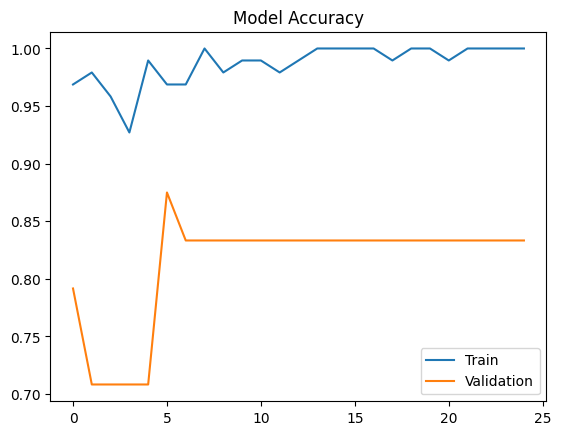

In [71]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


In [59]:
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode
import scipy.io.wavfile as wavfile

def record_audio(filename='test.wav', duration=2):
    js = Javascript('''
    async function recordAudio(duration) {
      const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
      const recorder = new MediaRecorder(stream);
      let chunks = [];

      recorder.ondataavailable = e => chunks.push(e.data);
      recorder.start();

      await new Promise(resolve => setTimeout(resolve, duration * 1000));
      recorder.stop();

      return new Promise(resolve => {
        recorder.onstop = async () => {
          const blob = new Blob(chunks);
          const arrayBuffer = await blob.arrayBuffer();
          resolve(btoa(String.fromCharCode(...new Uint8Array(arrayBuffer))));
        };
      });
    }
    ''')

    display(js)
    audio_base64 = output.eval_js(f"recordAudio({duration})")
    audio_bytes = b64decode(audio_base64)

    with open(filename, 'wb') as f:
        f.write(audio_bytes)

    print("Recording saved as", filename)

In [64]:
record_audio("test.wav", duration=2)

<IPython.core.display.Javascript object>

Recording saved as test.wav


In [68]:
def predict_realtime(file):
    features = extract_mfcc(file)
    features = pad_sequences([features], maxlen=X.shape[1], padding='post')

    prediction = model.predict(features)
    index = np.argmax(prediction)

    print("Predicted Command:", le.inverse_transform([index])[0])

predict_realtime("test.wav")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted Command: go


In [69]:
predict_realtime("test.wav")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted Command: go


In [70]:
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

Training Accuracy: 1.0
Validation Accuracy: 0.8333333134651184
